In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from scipy.interpolate import RectBivariateSpline

In [2]:
def adi_next_step(u, num_x, num_y, d1, d2, A_x, A_y):
    u_half = np.zeros_like(u) # Estado em n + 1/2

    # Congela o eixo y e resolve implicitamente em x

    for j in range(1, num_y - 1):
        # Resolve o lado direito da equação (dado por D1)
        D1 = np.zeros(num_x - 2)
        for i in range(1, num_x - 1):
            D1[i-1] = d2 * u[i, j+1] + (1 - 2*d2) * u[i, j] + d2 * u[i, j-1]

        # Adiciona condições de contorno
        D1[0] += d1 * u[0, j]
        D1[-1] += d1 * u[-1, j]
        
        # Resolve os sistemas tridiagonais pras linhas
        u_half[1:-1, j] = solve_banded((1, 1), A_x, D1)
        
    # Aplica as condições de contorno
    u_half[0, :] = u[0, :]
    u_half[-1, :] = u[-1, :]
    u_half[:, 0] = u[:, 0]
    u_half[:, -1] = u[:, -1]


    # Congela o eixo x e resolve implicitamente em y
    for i in range(1, num_x - 1):
        # Resolve o lado direito da equação (dado por D2)
        D2 = np.zeros(num_y - 2)
        for j in range(1, num_y - 1):
            D2[j-1] = d1 * u_half[i+1, j] + (1 - 2*d1) * u_half[i, j] + d1 * u_half[i-1, j]

        # Adiciona condições de contorno
        D2[0] += d2 * u_half[i, 0]
        D2[-1] += d2 * u_half[i, -1]
        
        # Resolve os sistemas tridiagonais pras colunas
        u[i, 1:-1] = solve_banded((1, 1), A_y, D2)

    # Armazena a matriz a cada passo de tempo, Transposta, para deixar os eixos corretos
    return u.copy()

In [3]:
def adi_next_step(u, num_x, num_y, d1, d2, A_x, A_y):
    u_half = np.zeros_like(u) # Estado em n + 1/2

    # Congela o eixo y e resolve implicitamente em x
    D1 = np.zeros((num_y - 2, num_x - 2))
    D1 = d2 * u[1:-1, 2:] + \
         (1 - 2*d2) * u[1:-1, 1:-1] + \
         d2 * u[1:-1, :-2]

    # Adiciona condições de contorno
    D1[0, :] += d1 * u[0, 1:-1]
    D1[-1, :] += d1 * u[-1, 1:-1]

    # Resolve os sistemas tridiagonais pras linhas
    u_half[1:-1, 1:-1] = solve_banded((1, 1), A_x, D1)
        
    # Aplica as condições de contorno
    u_half[0, :] = u[0, :]
    u_half[-1, :] = u[-1, :]
    u_half[:, 0] = u[:, 0]
    u_half[:, -1] = u[:, -1]

    # Congela o eixo x e resolve implicitamente em y
    D2 = np.zeros((num_x - 2, num_y - 2))
    D2 = d1 * u_half[2:, 1:-1] + \
         (1 - 2*d1) * u_half[1:-1, 1:-1] + \
         d1 * u_half[:-2, 1:-1]

    # Adiciona condições de contorno
    D2[:, 0] += d2 * u_half[1:-1, 0]
    D2[:, -1] += d2 * u_half[1:-1, -1]

    # Resolve os sistemas tridiagonais pras colunas
    u[1:-1, 1:-1] = (solve_banded((1, 1), A_y, D2.T)).T

    # Armazena a matriz a cada passo de tempo
    return u.copy()

def solve_heat_ADI(u_inicial, num_x, num_y, d1, d2, A_x, A_y, total_time = 4320.0, dt = 10.0):
    '''
    Função para resolver a equação do calor 2D usando o método ADI (Alternating Direction Implicit)
    '''
    u = u_inicial.copy()
    
    states = [] 
    states.append(u.copy())

    num_steps = int(total_time / dt)
    
    for n in range(num_steps):
        u = adi_next_step(u, num_x, num_y, d1, d2, A_x, A_y)
        states.append(u.copy())

    return states

def ftcs_next_step(u, gamma):
    u_new = u.copy()
    
    # Calculo do FTCS vetorizado
    u_new[1:-1, 1:-1] = u[1:-1, 1:-1] + gamma * (
        u[2:, 1:-1] +
        u[:-2, 1:-1] +
        u[1:-1, 2:] +
        u[1:-1, :-2] -
        4 * u[1:-1, 1:-1]
    )
    
    return u_new

def solve_heat_FTCS(u_inicial, gamma, total_time = 4320.0, dt = 10.0):
    '''
    Função para resolver a equação do calor 2D usando o método FTCS
    '''
    
    u = u_inicial.copy()
    
    states = [] 
    states.append(u.copy())

    num_steps = int(total_time / dt)
    
    for n in range(num_steps):
        u = ftcs_next_step(u, gamma)
        states.append(u.copy())

    return states

In [4]:
# Parâmetros físicos do material
k_x = 1.25
k_y = 1.25
density = 1
specific_heat = 1

boundary_temp = -17.778
initial_temp = -1.111 # 30ºF convertidos pra ºC (direto da malásia)

alpha_x = k_x / (density * specific_heat) * 1/3600 # Converte de m^2/h para m^2/s
alpha_y = k_y / (density * specific_heat) * 1/3600

size = (3.0, 3.0)

# Parâmetros da simulação
dx = 0.05
dy = 0.05

dt = (dx ** 2)/(4 * alpha_x) * 0.1
total_time = 4320

In [5]:
def init_ADI(size, dx, dy, dt, alpha_x, alpha_y, boundary, initial_temp):
    num_x, num_y = int(size[0]/dx) + 1, int(size[1]/dy) + 1

    # Parâmetros gerais
    d1 = alpha_x * (dt / 2.0) / (dx**2)
    d2 = alpha_y * (dt / 2.0) / (dy**2)

    # Já inicializa tudo com a temp. de contorno e depois preenche o resto
    u = np.full((num_x, num_y), boundary)
    u[1:-1, 1:-1] = initial_temp

    # Inicializa a matriz auxiliar pro implícito em X
    A_x = np.zeros((3, num_x - 2))
    A_x[0, 1:] = -d1           # Diagonal superior
    A_x[1, :]  = 1 + 2 * d1    # Diagonal principal
    A_x[2, :-1] = -d1          # Diagonal inferior

    # Inicializa a matriz auxiliar pro implícito em Y
    A_y = np.zeros((3, num_y - 2))
    A_y[0, 1:] = -d2           # Diagonal superior
    A_y[1, :]  = 1 + 2 * d2    # Diagonal principal
    A_y[2, :-1] = -d2          # Diagonal inferior

    return u, d1, d2, A_x, A_y

In [6]:
def init_FTCS(size, dx, dy, dt, alpha_x, boundary, initial_temp):
    num_x, num_y = int(round(size[0] / dx)) + 1, int(round(size[1] / dy)) + 1

    # Parâmetros gerais
    gamma = (alpha_x * dt) / (dx**2)

    # Já inicializa tudo com a temp. de contorno e depois preenche o resto
    u = np.full((num_x, num_y), boundary)
    u[1:-1, 1:-1] = initial_temp

    return u, gamma

In [7]:
u, d1, d2, A_x, A_y = init_ADI(size, dx, dy, dt, alpha_x, alpha_y, boundary_temp, initial_temp)
num_x, num_y = int(size[0]/dx) + 1, int(size[1]/dy) + 1

states_ADI = solve_heat_ADI(u, num_x, num_y, d1, d2, A_x, A_y, total_time=total_time, dt=dt)

In [8]:
%%time
#dt = 0.1
u, gamma = init_FTCS(size, dx, dy, dt, alpha_x, boundary_temp, initial_temp)
states_FTCS = solve_heat_FTCS(u, gamma, total_time=total_time, dt=dt)

CPU times: user 460 ms, sys: 165 ms, total: 625 ms
Wall time: 626 ms


In [9]:
def heat_semianalitycal_solution(x, y, t, Lx=3.0, Ly=3.0, kx=1.25, ky=1.25, termos=1000):
    ''' 
    Solução semianalítica da equação do calor 2D usando a série de Fourier, 
    considerando condições de contorno de Dirichlet. Pelas unidades usadas,
    as unidades de espaço e tempo são, respectivamente, metros e horas. 
    A temperatura é dada em ºC.
    '''
    
    temperature = 0
    
    # Caso x ou j sejam pares, o termo da soma é zero
    for n in range(1, termos+1, 2):
        for j in range(1, termos+1, 2):
            
            A_n = 120 / (n * j * np.pi**2) * 4
            
            temperature += A_n * np.sin(n * np.pi * x / Lx) * np.sin(j * np.pi * y / Ly) * \
                            np.exp(-((n**2 * kx / Lx**2 + j**2 * ky / Ly**2) * (np.pi**2) * t))
    
    return (temperature - 32) * 5/9 # Converte de ºF para ºC

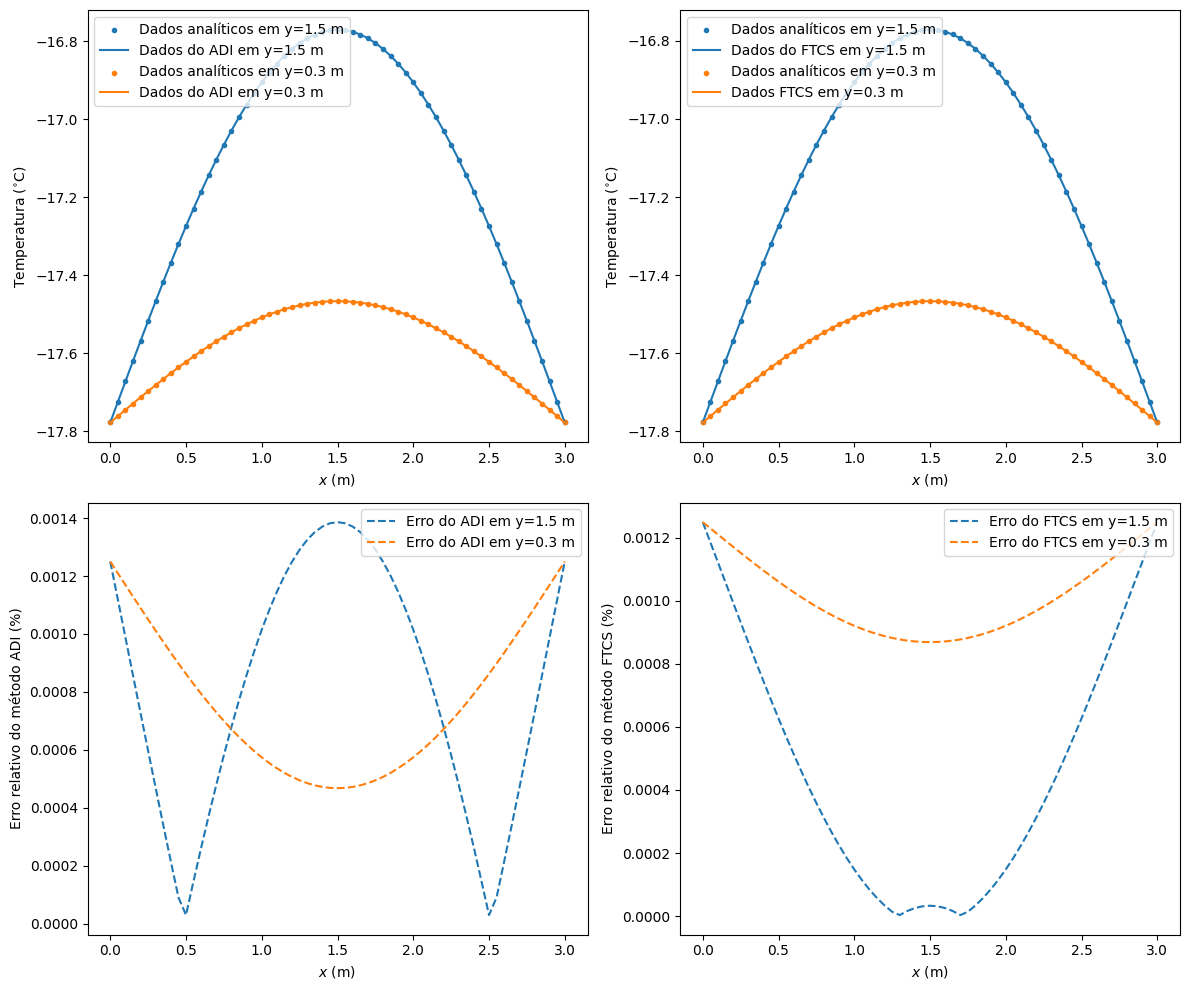

In [10]:
x = np.arange(0.0, 3 + dx, dx)

# resultados semi-analíticos
analytical_result_15 = heat_semianalitycal_solution(x, 1.5, 1.2, termos=1000)
analytical_result_03 = heat_semianalitycal_solution(x, 0.3, 1.2, termos=1000)

# Plot de comparação entre resultados semi-analíticos e resultados do ADI
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)

# resultados da simulação no último frame nas mesmas posições de y do semi-analitico
sim_y_as_15 = int(round(1.5 / dx))
adi_15 = states_ADI[-1][:, sim_y_as_15]
ftcs_15 = states_FTCS[-1][:, sim_y_as_15]

sim_y_as_03 = int(round(0.3 / dx))
adi_03 = states_ADI[-1][:, sim_y_as_03]
ftcs_03 = states_FTCS[-1][:, sim_y_as_03]

#ADI
plt.scatter(x, analytical_result_15, marker='.', label='Dados analíticos em y=1.5 m')
plt.plot(x, adi_15, label='Dados do ADI em y=1.5 m')

plt.scatter(x, analytical_result_03, marker='.', label='Dados analíticos em y=0.3 m')
plt.plot(x, adi_03, label='Dados do ADI em y=0.3 m')

plt.legend(loc="upper left")
plt.xlabel(r'$x$ (m)')
plt.ylabel(r'Temperatura ($^{\circ}$C)')

# Plot de comparação entre resultados semi-analíticos e resultados do ADI
plt.subplot(2, 2, 2)

#FTCS
plt.scatter(x, analytical_result_15, marker='.', label='Dados analíticos em y=1.5 m')
plt.plot(x, ftcs_15, label='Dados do FTCS em y=1.5 m')

plt.scatter(x, analytical_result_03, marker='.', label='Dados analíticos em y=0.3 m')
plt.plot(x, ftcs_03, label='Dados FTCS em y=0.3 m')

plt.legend(loc="upper left")
plt.xlabel(r'$x$ (m)')
plt.ylabel(r'Temperatura ($^{\circ}$C)')

# Plot dos erros do ADI
plt.subplot(2, 2, 3)

epsilon = 1e-12
error_15 = 100 * np.abs((adi_15 - analytical_result_15) / (analytical_result_15 + epsilon))
error_03 = 100 * np.abs((adi_03 - analytical_result_03) / (analytical_result_03 + epsilon))

plt.plot(x, error_15, label='Erro do ADI em y=1.5 m', linestyle='--')
plt.plot(x, error_03, label='Erro do ADI em y=0.3 m', linestyle='--')

plt.legend(loc="upper right")
plt.xlabel(r'$x$ (m)')
plt.ylabel(r'Erro relativo do método ADI (%)')

# Plot dos erros do FTCS
plt.subplot(2, 2, 4)

epsilon = 1e-12
error_15 = 100 * np.abs((ftcs_15 - analytical_result_15) / (analytical_result_15 + epsilon))
error_03 = 100 * np.abs((ftcs_03 - analytical_result_03) / (analytical_result_03 + epsilon))

plt.plot(x, error_15, label='Erro do FTCS em y=1.5 m', linestyle='--')
plt.plot(x, error_03, label='Erro do FTCS em y=0.3 m', linestyle='--')

plt.legend(loc="upper right")
plt.xlabel(r'$x$ (m)')
plt.ylabel(r'Erro relativo do método FTCS (%)')

plt.tight_layout()
plt.show()

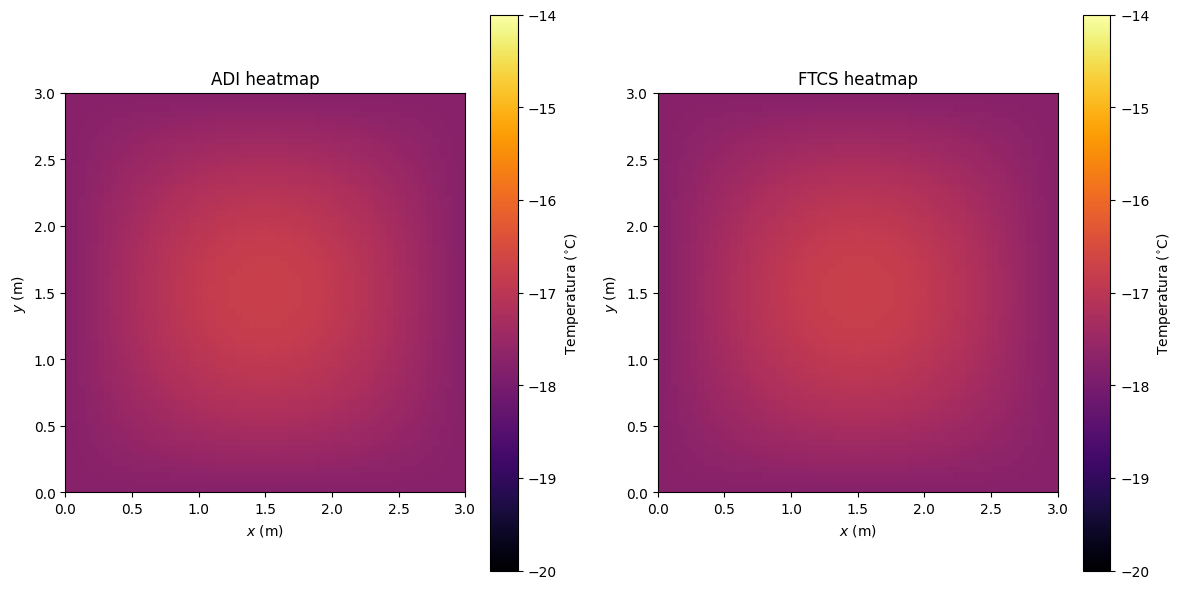

In [11]:
fig = plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(states_ADI[-1], cmap='inferno', origin='upper', extent=[0, 3, 0, 3], vmin=-20, vmax=-14)
plt.title("ADI heatmap")
plt.xlabel(r"$x$ (m)")
plt.ylabel(r"$y$ (m)")
plt.colorbar(label=r"Temperatura ($^{\circ}$C)")

plt.subplot(1, 2, 2)
plt.imshow(states_FTCS[-1], cmap='inferno', origin='upper', extent=[0, 3, 0, 3], vmin=-20, vmax=-14)
plt.title("FTCS heatmap")
plt.xlabel(r"$x$ (m)")
plt.ylabel(r"$y$ (m)")
plt.colorbar(label=r"Temperatura ($^{\circ}$C)")

plt.tight_layout()
plt.show()

In [12]:
from pymgrit.core.vector import Vector
from pymgrit.core.application import Application
from pymgrit.core.mgrit import Mgrit

class VectorPDE2D(Vector):
    def __init__(self, data=None):
        super().__init__()
        # Armazena diretamente a referência, sem fazer cópias ocultas
        self.data = data

    def clone(self):
        # A cópia deve ser feita apenas no clone, quando estritamente solicitada
        return VectorPDE2D(self.data.copy())

    def clone_zero(self):
        return VectorPDE2D(np.zeros_like(self.data))

    def clone_rand(self):
        return VectorPDE2D(np.random.rand(*self.data.shape).astype(np.float32))

    def pack(self):
        # O Numpy e o MPI já dão conta de transmitir essa matriz perfeitamente
        return self.data

    def unpack(self, vals):
        self.data = vals

    def set_values(self, v):
        self.data = v

    def get_values(self):
        return self.data

    def norm(self):
        return np.linalg.norm(self.data)

    def __add__(self, other):
        # O numpy já cria uma nova matriz do lado de fora, o init só vai guardá-la
        return VectorPDE2D(self.data + other.data)

    def __sub__(self, other):
        return VectorPDE2D(self.data - other.data)

    def __mul__(self, val):
        return VectorPDE2D(self.data * val)


class Heat2D(Application):
    def __init__(self, size, alpha_x, alpha_y, dx, dy, boundary, 
                initial_temp, t_start, t_stop, nt, method='FTCS'):

        super().__init__(t_start, t_stop, nt)

        self.nx = int(round(size[0] / dx)) + 1
        self.ny = int(round(size[1] / dy)) + 1

        dt = (t_stop - t_start) / (nt - 1)

        self.method = method

        if method == 'FTCS':
            u0, gamma = init_FTCS(size, dx, dy, dt, alpha_x, boundary, initial_temp)
            self.u0 = u0.copy()
            self.gamma = gamma
        elif method == 'ADI':
            u0_adi, d1, d2, Ax, Ay = init_ADI(size, dx, dy, dt, alpha_x, alpha_y, boundary, initial_temp)
            self.u0 = u0_adi.copy()
            self.d1, self.d2, self.Ax, self.Ay = d1, d2, Ax, Ay
        
        self.vector_t_start = VectorPDE2D(self.u0)
        self.vector_template = VectorPDE2D(np.zeros((self.nx, self.ny)))

    def step(self, u_start: VectorPDE2D, t_start: float, t_stop: float) -> VectorPDE2D:
        u = u_start.get_values().copy()
        
        if self.method == 'FTCS':
            u = ftcs_next_step(u, self.gamma)
        elif self.method == 'ADI':
            u = adi_next_step(u, self.nx, self.ny, self.d1, self.d2, self.Ax, self.Ay)
        
        return VectorPDE2D(u)

class TransferPDE2D:
    def __init__(self, size_x, size_y, nx_fino, ny_fino, nx_grosso, ny_grosso):
        self.nx_f = nx_fino
        self.ny_f = ny_fino
        self.nx_g = nx_grosso
        self.ny_g = ny_grosso
        
        self.x_f = np.linspace(0, size_x, self.nx_f)
        self.y_f = np.linspace(0, size_y, self.ny_f)
        self.x_g = np.linspace(0, size_x, self.nx_g)
        self.y_g = np.linspace(0, size_y, self.ny_g)

        self.step_x = (self.nx_f - 1) // (self.nx_g - 1)
        self.step_y = (self.ny_f - 1) // (self.ny_g - 1)

    def restriction(self, u):
        """ Pega os pontos coincidentes das malhas """
        data_f = u.get_values()
        
        # Pega só os pontos iguais nas duas malhas
        data_g = data_f[::self.step_x, ::self.step_y]

        return VectorPDE2D(data_g)

    def interpolation(self, u):
        """ Interpola da grid grossa para o grid fina """
        data_g = u.get_values()
        
        # interpolação bilinear
        interpolador = RectBivariateSpline(self.x_g, self.y_g, data_g, kx=1, ky=1)
        data_f = interpolador(self.x_f, self.y_f)
        
        return VectorPDE2D(data_f)

In [13]:
path_pymgrit = "pyMGRIT"
os.makedirs(path_pymgrit, exist_ok=True)

## Função para armazenar a solução do método Parareal em cada iteração
def output_parareal(self):
    # # Nome da pasta para armazenar a solução
    # path = 'results/' + 'dahlquist' + '/' + str(self.solve_iter)
    # # Cria a pasta, caso ela não exista
    # pathlib.Path(path).mkdir(parents=True, exist_ok=True)
    # Nome do arquivo de saída
    ##fname = path + '/dahlquist' + str(self.comm_time_rank)
    fname = 'calor_iter' + str(self.solve_iter) + '_rank' + str(self.comm_time_rank)
    fname = path_pymgrit + "/" + fname
    # Salva a solução em um arquivo
    # Save solution to file; here, we have nx solution values at each time point.
    np.save(fname,
                [[[self.t[0][i], self.u[0][i]] for i in self.index_local[0]]])
    # # Baixa o arquivo do Google Colab
    # files.download(fname + '.npy')

## Função para armazenar a solução de referência
def output_ref(self):
    # # Nome da pasta para armazenar a solução
    # path = 'results/' + 'dahlquist_ref' + '/' + str(self.solve_iter)
    # # Cria a pasta, caso ela não exista
    # pathlib.Path(path).mkdir(parents=True, exist_ok=True)
    # Nome do arquivo de saída
    fname = 'calor_ref_rank' + str(self.comm_time_rank)
    fname = path_pymgrit + "/" + fname
    # Salva a solução em um arquivo
    # Save solution to file; here, we have nx solution values at each time point.
    np.save(fname,
                [[[self.t[0][i], self.u[0][i]] for i in self.index_local[0]]])
    # # Baixa o arquivo do Google Colab
    # files.download(fname + '.npy')

In [16]:
t_start = 0.0
t_stop = total_time

nt_slices = 9 # slices do parareal
time_por_slice = total_time/(nt_slices - 1)
tol = 1e-2

# Parâmetros da simulação
dx_0, dy_0 = dx, dy # 60x60
dt_0 = dt
passos_total_L0 = int(total_time / dt_0)
passos_L0_por_slice = passos_total_L0 // (nt_slices - 1)

dx_1, dy_1 = 0.2, 0.2 # 15x15
cf_0_1 = passos_L0_por_slice // 2
passos_L1_por_slice = passos_L0_por_slice // cf_0_1

# Total de pontos no tempo para a biblioteca
nt_1 = (nt_slices - 1) * passos_L1_por_slice + 1
nt_0 = (nt_1 - 1) * cf_0_1 + 1

calor_level_0 = Heat2D(size, alpha_x, alpha_y, dx_0, dy_0, boundary_temp, 
                initial_temp, 0.0, total_time, nt_0, method='FTCS')
                
calor_level_1 = Heat2D(size, alpha_x, alpha_y, dx_1, dy_1, boundary_temp, 
                initial_temp, 0.0, total_time, nt_1, method='ADI')

calor_level_1.t = calor_level_0.t[::cf_0_1]

# Array contendo todos os níveis de discretização
problem = [calor_level_0, calor_level_1]

cf_iter = int((nt_1 - 1) / (nt_slices - 1)) - 1

transfer_ops = [
        # Transferência entre L0 (Fino) e L1 (Grosso)
        TransferPDE2D(size[0], size[1], 
                    calor_level_0.nx, calor_level_0.ny, 
                    calor_level_1.nx, calor_level_1.ny)
    ]

parareal_calor = Mgrit(
                            problem=problem,
                            max_iter=10,
                            tol=tol,
                            cycle_type='V',
                            cf_iter=cf_iter,
                            #output_fcn=output_parareal,
                            #output_lvl=1,
                            transfer=transfer_ops
                        )

parareal_calor.solve()

## Apenas um nível de discretização (o fino)
problem_ref = [calor_level_0]

## Instância da da classe Mgrit com apenas um nível e uma iteração
mgrit_ref = Mgrit(
                    problem=problem_ref,
                    #output_fcn=output_ref,
                    max_iter=1,
                    tol=1e-7
                )

## Execução da simulação de referência
info_ref = mgrit_ref.solve()

INFO - 13-04-26 05:06:17 - Start setup
INFO - 13-04-26 05:06:20 - Setup took 2.26865291595459 s
INFO - 13-04-26 05:06:20 - Start solve
INFO - 13-04-26 05:06:21 - iter 1  | conv: 0.3223139744573509      | conv factor: -                     | runtime: 1.5795834064483643 s   
INFO - 13-04-26 05:06:22 - iter 2  | conv: 0.003938381069841393    | conv factor: 0.012219082577701037  | runtime: 1.0399665832519531 s   
INFO - 13-04-26 05:06:22 - Solve took 2.6224801540374756 s
INFO - 13-04-26 05:06:22 - Run parameter overview
  time interval             : [0.0, 4320.0]
  number of time points     : 23985
  max dt                    : 0.18012008005371172
  number of levels          : 2
  coarsening factors        : [1499]
  relaxation weight         : 1.0
  cf_iter                   : 1
  nested iteration          : True
  cycle type                : V
  stopping tolerance        : 0.01
  time communicator size    : 1
  space communicator size   : 1
INFO - 13-04-26 05:06:22 - Start setup
INFO - 1